# IPL Exploratory Data Analysis & Analytics Engine

This notebook orchestrates the reusable analytics engine in the `src/analytics/` package to perform dataset profiling, compute executive summaries, analyze seasons, teams, venues, matches, players, and head-to-head records, and export analytical outputs.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from config.paths import STAGING_DIR, ANALYTICS_DATA_DIR
from src.analytics.profiler import profile_dataset
from src.analytics.summary import compute_executive_summary
from src.analytics.season_analysis import analyze_seasons
from src.analytics.team_analysis import analyze_teams
from src.analytics.venue_analysis import analyze_venues
from src.analytics.match_analysis import analyze_matches
from src.analytics.player_analysis import analyze_players
from src.analytics.head_to_head import analyze_head_to_head
from src.analytics.visualization import (
    plot_bar,
    plot_horizontal_bar,
    plot_line,
    plot_pie,
    plot_histogram,
    plot_box,
    plot_heatmap,
    save_figure,
    close_all_figures
)

## 2. Load Processed Dataset

In [2]:
dataset_path = STAGING_DIR / "match_info_processed.parquet"
df = pd.read_parquet(dataset_path)
print(f"Loaded processed dataset from: {dataset_path}")
print(f"Dataset shape: {df.shape}")

Loaded processed dataset from: D:\IPL-Analytics-Strategy-Platform\data\processed\staging\match_info_processed.parquet
Dataset shape: (1243, 36)


## 3. Dataset Profiling

In [3]:
profile = profile_dataset(df)
print("Dataset Profile Metadata:")
for key, val in profile["metadata"].items():
    if key != "memory":
        print(f"  {key}: {val}")
    else:
        print(f"  total_memory_mb: {val['total_memory_mb']} MB")

print(
    f"\nDuplicate rows found: {profile['metadata']['duplicates']['duplicate_rows']}"
)

print("\nDataset Column Summary (first 10 rows):")
display(profile["profiles"]["columns"].head(10))

Dataset Profile Metadata:
  shape: {'rows': 1243, 'columns': 36}
  total_memory_mb: 1.37 MB
  duplicates: {'duplicate_rows': 0, 'duplicate_pct': 0.0}

Duplicate rows found: 0

Dataset Column Summary (first 10 rows):


,column,dtype,non_null,null,unique,null_pct,cardinality_pct
0,stage,float64,0,1243,0,100.00,0.00
1,method,object,23,1220,1,98.15,0.08
2,winner_runs,Int64,558,685,104,55.11,8.37
3,winner_wickets,Int64,660,583,10,46.90,0.80
4,match_number,Int64,1169,74,72,5.95,5.79
5,city,object,1192,51,36,4.10,2.90
6,winning_margin,Int64,1218,25,104,2.01,8.37
7,winner,object,1218,25,17,2.01,1.37
8,win_type,object,1218,25,2,2.01,0.16
9,player_of_match,object,1234,9,321,0.72,25.82


## 4. Executive Summary

In [4]:
summary = compute_executive_summary(df)
print("Executive IPL Metrics:")
print("=" * 40)
for key, val in summary.items():
    print(f"{key:<25}: {val}")
print("=" * 40)

Executive IPL Metrics:
total_matches            : 1243
total_seasons            : 18
total_teams              : 17
total_venues             : 47
total_cities             : 36
completed_matches        : 1218
no_result_matches        : 25
win_by_runs              : 558
win_by_wickets           : 660
toss_field_percentage    : 66.37


## 5. Season Analysis

In [5]:
season_results = analyze_seasons(df)
print("Seasons analyzed. Sub-reports computed:")
for key in season_results.keys():
    print(f"- {key}")

print("\nMatches played per Season:")
display(season_results["matches"].head())

Seasons analyzed. Sub-reports computed:
- matches
- teams
- venues
- player_of_match
- toss
- outcomes
- margins

Matches played per Season:


,season,matches
0,2008,58
1,2009,57
2,2010,60
3,2011,73
4,2012,74


## 6. Team Analysis

In [6]:
team_results = analyze_teams(df)
print("Teams analyzed. Sub-reports computed:")
for key in team_results.keys():
    print(f"- {key}")

print("\nTeam Wins Summary:")
display(team_results["wins"].head())

Teams analyzed. Sub-reports computed:
- participation
- wins
- toss
- season
- venue
- margins

Team Wins Summary:


,team,wins
0,Chennai Super Kings,148
1,Deccan Chargers,29
2,Delhi Capitals,58
3,Delhi Daredevils,67
4,Gujarat Lions,13


## 7. Venue Analysis

In [7]:
venue_results = analyze_venues(df)
print("Venues analyzed. Sub-reports computed:")
for key in venue_results.keys():
    print(f"- {key}")

print("\nVenue Match Counts (first 5 venues):")
display(venue_results["matches"].head())

Venues analyzed. Sub-reports computed:
- matches
- teams
- season
- toss
- margins

Venue Match Counts (first 5 venues):


,venue,matches
0,"Arun Jaitley Stadium, Delhi",44
1,Barabati Stadium,7
2,"Barsapara Cricket Stadium, Guwahati",8
3,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,29
4,"Brabourne Stadium, Mumbai",27


## 8. Match Analysis

In [8]:
match_results = analyze_matches(df)
print("Match outcomes analyzed. Sub-reports computed:")
for key in match_results.keys():
    print(f"- {key}")

print("\nMatch Result Type Distribution:")
display(match_results["results"])

Match outcomes analyzed. Sub-reports computed:
- match_types
- results
- toss
- toss_advantage
- margins

Match Result Type Distribution:


,metric,value
0,wins_by_runs,558
1,wins_by_wickets,660
2,no_results,25


## 9. Player Analysis

In [9]:
player_results = analyze_players(df)
print("Players analyzed. Sub-reports computed:")
for key in player_results.keys():
    print(f"- {key}")

print("\nMost Player of the Match Awards:")
display(player_results["awards"].head())

Players analyzed. Sub-reports computed:
- awards
- season
- team
- venue
- match_type

Most Player of the Match Awards:


,player,awards
0,A Chandila,1
1,A Kumble,3
2,A Manohar,1
3,A Mishra,12
4,A Nehra,6


## 10. Head-to-Head Analysis

In [10]:
h2h_results = analyze_head_to_head(df)
print("Head-to-head records analyzed. Sub-reports computed:")
for key in h2h_results.keys():
    print(f"- {key}")

print("\nMatches played between team pairs:")
display(h2h_results["matches"].head())

Head-to-head records analyzed. Sub-reports computed:
- matches
- wins
- season
- venue
- margins

Matches played between team pairs:


,team_a,team_b,matches
0,Chennai Super Kings,Deccan Chargers,10
1,Chennai Super Kings,Delhi Capitals,15
2,Chennai Super Kings,Delhi Daredevils,18
3,Chennai Super Kings,Gujarat Titans,10
4,Chennai Super Kings,Kings Xi Punjab,23


## 11. Visualizations

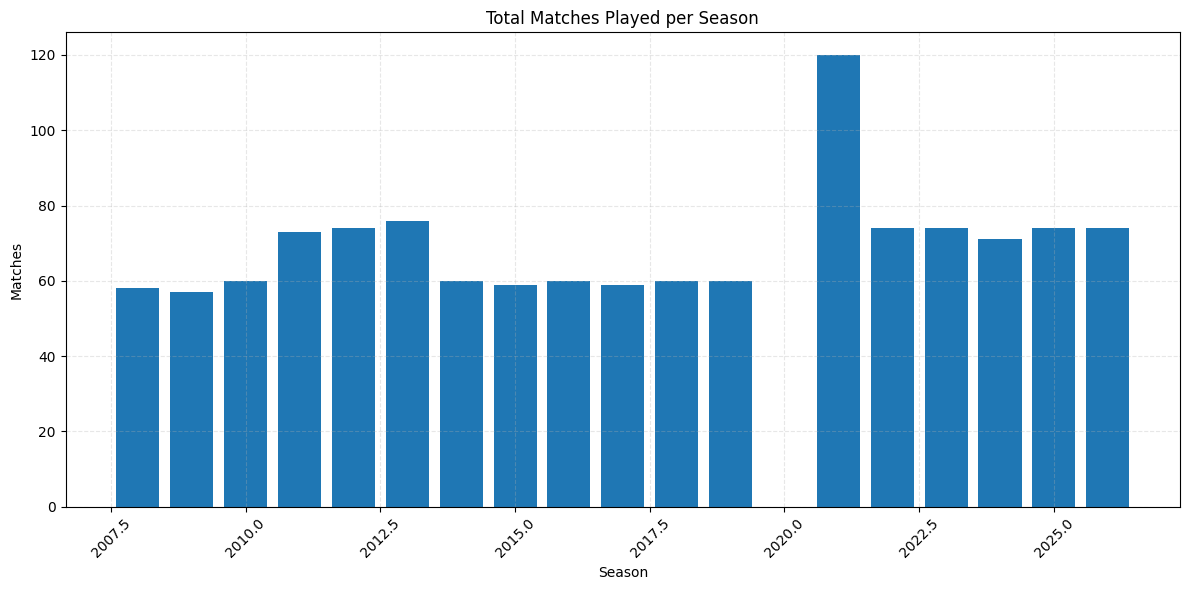

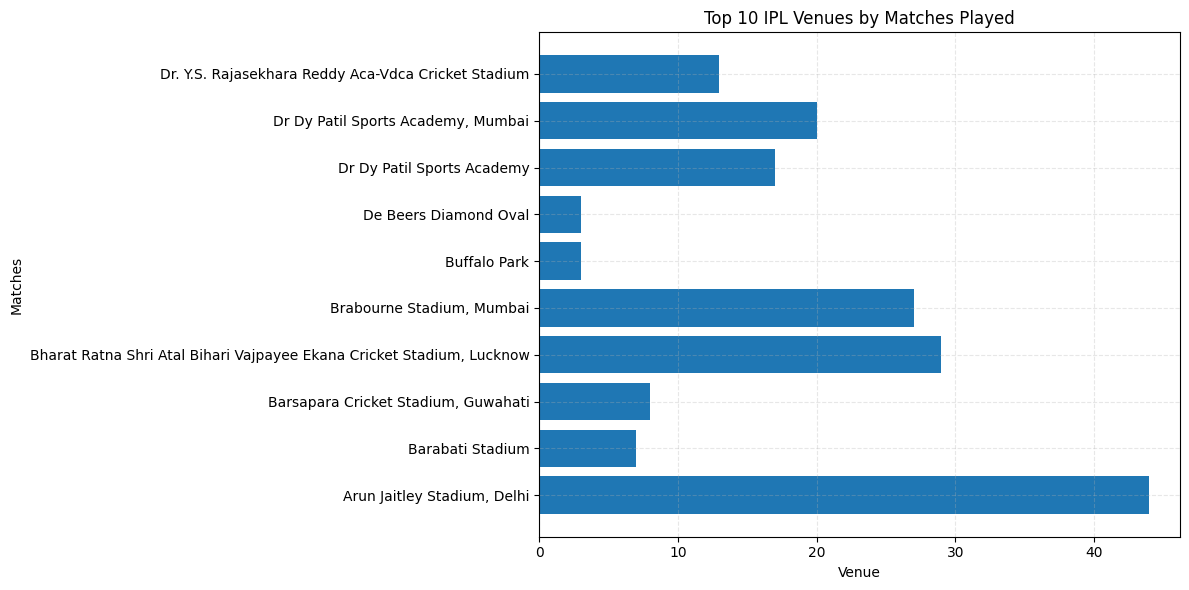

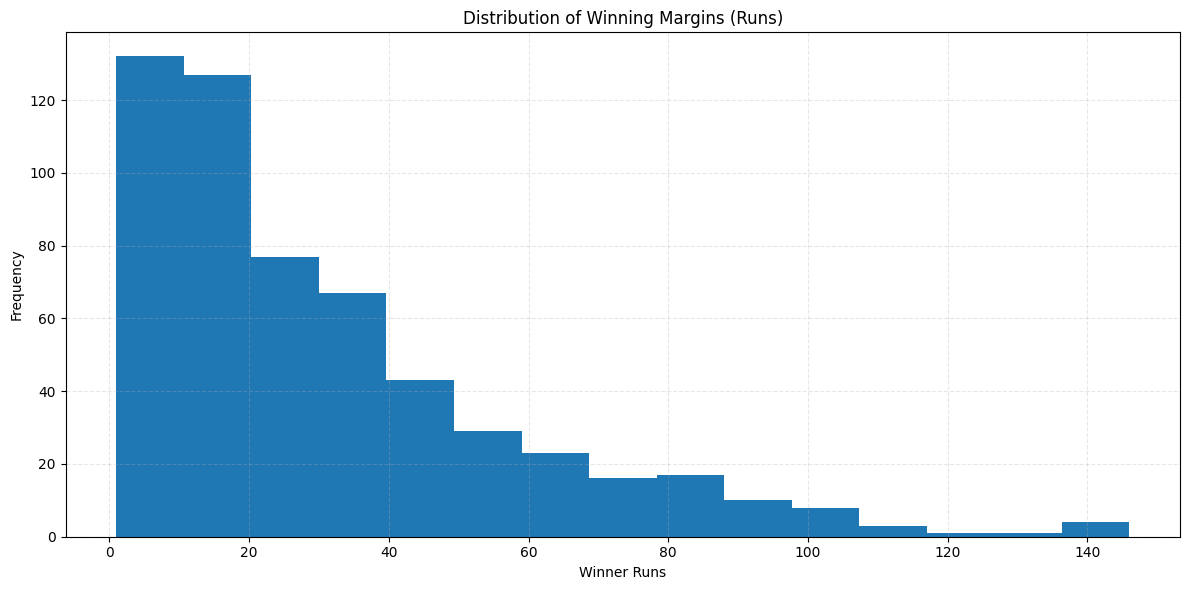

In [11]:
# 1. Total matches per season
matches_per_season = season_results["matches"]
plot_bar(
    df=matches_per_season,
    x_col="season",
    y_col="matches",
    title="Total Matches Played per Season",
    xlabel="Season",
    ylabel="Matches"
)
save_figure(STAGING_DIR / "matches_per_season.png")
plt.show()

# 2. Top 10 venues with most matches
top_venues = venue_results["matches"].head(10)
plot_horizontal_bar(
    df=top_venues,
    x_col="venue",
    y_col="matches",
    title="Top 10 IPL Venues by Matches Played",
    xlabel="Venue",
    ylabel="Matches"
)
save_figure(STAGING_DIR / "top_venues.png")
plt.show()

# 3. Winning margin distribution (Histogram)
runs_win_matches = df[df["winner_runs"] > 0]
plot_histogram(
    df=runs_win_matches,
    column="winner_runs",
    title="Distribution of Winning Margins (Runs)",
    xlabel="Winner Runs",
    ylabel="Frequency",
    bins=15
)
save_figure(STAGING_DIR / "winning_margin_runs_dist.png")
plt.show()

## 12. Export Analytics Outputs

In [12]:
import os
import json

# Create output folders inside STAGING_DIR if they don't exist
staging_analytics = ANALYTICS_DATA_DIR
staging_analytics.mkdir(parents=True, exist_ok=True)

# Save season aggregates
for key, s_df in season_results.items():
    s_df.to_parquet(staging_analytics / f"season_{key}.parquet", index=False)
    s_df.to_csv(staging_analytics / f"season_{key}.csv", index=False)

# Save team aggregates
for key, t_df in team_results.items():
    t_df.to_parquet(staging_analytics / f"team_{key}.parquet", index=False)
    t_df.to_csv(staging_analytics / f"team_{key}.csv", index=False)

# Save venue aggregates
for key, v_df in venue_results.items():
    v_df.to_parquet(staging_analytics / f"venue_{key}.parquet", index=False)
    v_df.to_csv(staging_analytics / f"venue_{key}.csv", index=False)

# Save match aggregates
for key, m_df in match_results.items():
    m_df.to_parquet(staging_analytics / f"match_{key}.parquet", index=False)
    m_df.to_csv(staging_analytics / f"match_{key}.csv", index=False)

# Save player aggregates
for key, p_df in player_results.items():
    p_df.to_parquet(staging_analytics / f"player_{key}.parquet", index=False)
    p_df.to_csv(staging_analytics / f"player_{key}.csv", index=False)

# Save head-to-head aggregates
for key, h_df in h2h_results.items():
    h_df.to_parquet(staging_analytics / f"h2h_{key}.parquet", index=False)
    h_df.to_csv(staging_analytics / f"h2h_{key}.csv", index=False)

# Save executive summary as JSON
with open(staging_analytics / "executive_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(f"Successfully exported all analytics data outputs to {staging_analytics}")

Successfully exported all analytics data outputs to D:\IPL-Analytics-Strategy-Platform\data\analytics


## 13. Notebook Summary

In [13]:
print("==================================================================================")
print("IPL Exploratory Analysis Notebook Execution Completed!")
print("All profiling, summaries, seasonal, team, venue, match, player, and head-to-head")
print("analyses have been successfully executed, visualized, and exported to staging.")
print("==================================================================================")

IPL Exploratory Analysis Notebook Execution Completed!
All profiling, summaries, seasonal, team, venue, match, player, and head-to-head
analyses have been successfully executed, visualized, and exported to staging.
